## CNN ON CATS AND DOGS

In [8]:
#data loading 

train_path="cnn_dataset/training"
test_path="cnn_dataset/testing"

import shutil
shutil.rmtree("cnn_dataset/training/.ipynb_checkpoints", ignore_errors=True)
shutil.rmtree("cnn_dataset/testing/.ipynb_checkpoints", ignore_errors=True)

#rescaling

from tensorflow.keras.preprocessing.image import ImageDataGenerator #normalize pixel values from 0-255 to 0-1
train=ImageDataGenerator(rescale=1./255)
test=ImageDataGenerator(rescale=1./255)

train_data=train.flow_from_directory(train_path, target_size=(64,64), batch_size=32, class_mode='binary')
test_data=test.flow_from_directory(test_path, target_size=(64,64), batch_size=32, class_mode='binary')

Found 3794 images belonging to 2 classes.
Found 2024 images belonging to 2 classes.


In [9]:
#cnn model building

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model=Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))  #features
model.add(MaxPooling2D(pool_size=(2,2)))  #reduces size + keeps imp info
model.add(Conv2D(64, (3,3), activation='relu'))  #more feat
model.add(MaxPooling2D(pool_size=(2,2)))  #more reduce
model.add(Flatten())  #2d to 1d
model.add(Dense(128, activation='relu'))  #fully connected
model.add(Dense(1, activation='sigmoid'))  #predict

#compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [10]:
#training

history=model.fit(train_data, epochs=5, validation_data=test_data)

Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step - accuracy: 0.6070 - loss: 0.6548 - val_accuracy: 0.6640 - val_loss: 0.6023
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - accuracy: 0.6911 - loss: 0.5800 - val_accuracy: 0.6823 - val_loss: 0.5827
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.7528 - loss: 0.5031 - val_accuracy: 0.6779 - val_loss: 0.6156
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 113ms/step - accuracy: 0.7960 - loss: 0.4441 - val_accuracy: 0.7273 - val_loss: 0.5634
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 111ms/step - accuracy: 0.8332 - loss: 0.3825 - val_accuracy: 0.7179 - val_loss: 0.6200


In [12]:
#eval

loss, acc=model.evaluate(test_data)
print(acc)

#prediction

import numpy as np
sample=next(test_data)[0]
pred=model.predict(sample)
print(pred[:5])

64/64 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7179 - loss: 0.6200
0.7178853750228882
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
[[0.30444634]
 [0.09384489]
 [0.26572388]
 [0.83428985]
 [0.28478363]]


## CMP WITH ANN

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

ann=Sequential()
ann.add(Flatten(input_shape=(64,64,3)))
ann.add(Dense(128, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

ann.fit(train_data, epochs=5, validation_data=test_data)

y_pred_ann=ann.predict(test_data)
y_pred_ann=(y_pred_ann>=0.5).astype(int)
y_true=test_data.classes

from sklearn.metrics import accuracy_score
print("ann accuracy:", accuracy_score(y_true, y_pred_ann))

C:\Users\anjan\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 13s 98ms/step - accuracy: 0.5403 - loss: 0.9908 - val_accuracy: 0.5010 - val_loss: 1.0034
Epoch 2/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.5506 - loss: 0.7695 - val_accuracy: 0.5247 - val_loss: 0.7630
Epoch 3/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0.5551 - loss: 0.8142 - val_accuracy: 0.5292 - val_loss: 0.8137
Epoch 4/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 96ms/step - accuracy: 0.5907 - loss: 0.6904 - val_accuracy: 0.5716 - val_loss: 0.6788
Epoch 5/5
119/119 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.6139 - loss: 0.6560 - val_accuracy: 0.6003 - val_loss: 0.6730
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step
ann accuracy: 0.4925889328063241


## EVAL VIZ

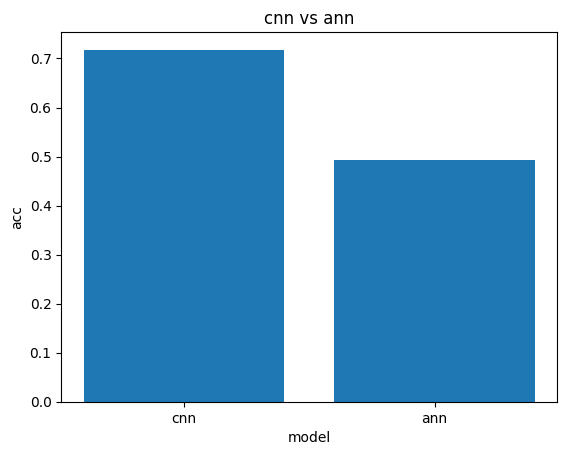

In [14]:
import matplotlib.pyplot as plt

cnn_acc=acc
ann_acc=accuracy_score(y_true, y_pred_ann)

models=["cnn", "ann"]
scores=[cnn_acc, ann_acc]
plt.bar(models, scores)
plt.title("cnn vs ann")
plt.xlabel("model")
plt.ylabel("acc")
plt.show()